# Step 3 — Preprocessing & Train/Val/Test Split
**Goals**:
1. Outlier & missing value analysis
2. Empty slice filtering (brain coverage threshold)
3. Z-score normalisation demonstration (before vs after)
4. Compare 3 split strategies → select the most balanced
5. Build PyTorch DataLoader and verify batch shapes
6. Save final split to `split.json`

In [1]:
import os, sys, json, random
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

# Make src/ importable
sys.path.insert(0, os.path.abspath('.'))
from src.dataset import (
    clip_outliers, zscore_normalise, count_outlier_voxels,
    load_subject, get_valid_slice_indices, BraTSDataset, MODALITIES
)

import torch
from torch.utils.data import DataLoader

TRAIN_DIR = os.path.join('PKG - BraTS-PEDs-v1', 'BraTS-PEDs-v1', 'Training')
subjects = sorted(os.listdir(TRAIN_DIR))
subject_list = [(os.path.join(TRAIN_DIR, s), s) for s in subjects]
print(f'Total subjects: {len(subject_list)}')

Total subjects: 257


## 1. Missing Values & Outlier Analysis

In [2]:
# Scan a sample of 10 subjects for outlier voxels (>5σ) and NaN/Inf
sample_subjects = subject_list[:10]
outlier_report = []

for subj_dir, subj_id in tqdm(sample_subjects, desc='QC scan'):
    row = {'subject': subj_id}
    for mod in MODALITIES:
        vol = nib.load(os.path.join(subj_dir, f'{subj_id}-{mod}.nii.gz')).get_fdata().astype(np.float32)
        has_nan  = bool(np.isnan(vol).any())
        has_inf  = bool(np.isinf(vol).any())
        n_out, frac_out = count_outlier_voxels(vol, sigma_threshold=5.0)
        p99_5 = float(np.percentile(vol[vol > 0], 99.5)) if (vol > 0).any() else 0.0
        row[mod] = {'nan': has_nan, 'inf': has_inf, 'outlier_n': n_out,
                    'outlier_frac': round(frac_out * 100, 3), 'p99.5': round(p99_5, 1)}
    outlier_report.append(row)

# Summary table
print(f'\n{"Subject":<25} {"Modality":<8} {"NaN":<6} {"Inf":<6} {"Outliers >5σ":<15} {"P99.5"}')
print('-' * 75)
for row in outlier_report:
    for mod in MODALITIES:
        d = row[mod]
        print(f"{row['subject']:<25} {mod:<8} {str(d['nan']):<6} {str(d['inf']):<6} "
              f"{d['outlier_n']:>6} ({d['outlier_frac']:.3f}%)  {d['p99.5']:>8}")

QC scan: 100%|██████████| 10/10 [00:15<00:00,  1.58s/it]


Subject                   Modality NaN    Inf    Outliers >5σ    P99.5
---------------------------------------------------------------------------
BraTS-PED-00001-000       t1c      False  False    3407 (0.040%)     811.4
BraTS-PED-00001-000       t1n      False  False      13 (0.000%)     874.7
BraTS-PED-00001-000       t2f      False  False      43 (0.001%)     692.4
BraTS-PED-00001-000       t2w      False  False   20453 (0.309%)    1686.6
BraTS-PED-00002-000       t1c      False  False    6872 (0.086%)     477.0
BraTS-PED-00002-000       t1n      False  False       6 (0.000%)     530.3
BraTS-PED-00002-000       t2f      False  False      16 (0.000%)     342.8
BraTS-PED-00002-000       t2w      False  False   41911 (0.751%)    1334.2
BraTS-PED-00003-000       t1c      False  False    1743 (0.026%)     787.5
BraTS-PED-00003-000       t1n      False  False     318 (0.006%)     778.7
BraTS-PED-00003-000       t2f      False  False    3133 (0.054%)     320.0
BraTS-PED-00003-000       t

## 2. Normalisation Demo: Raw → Clip → Z-score

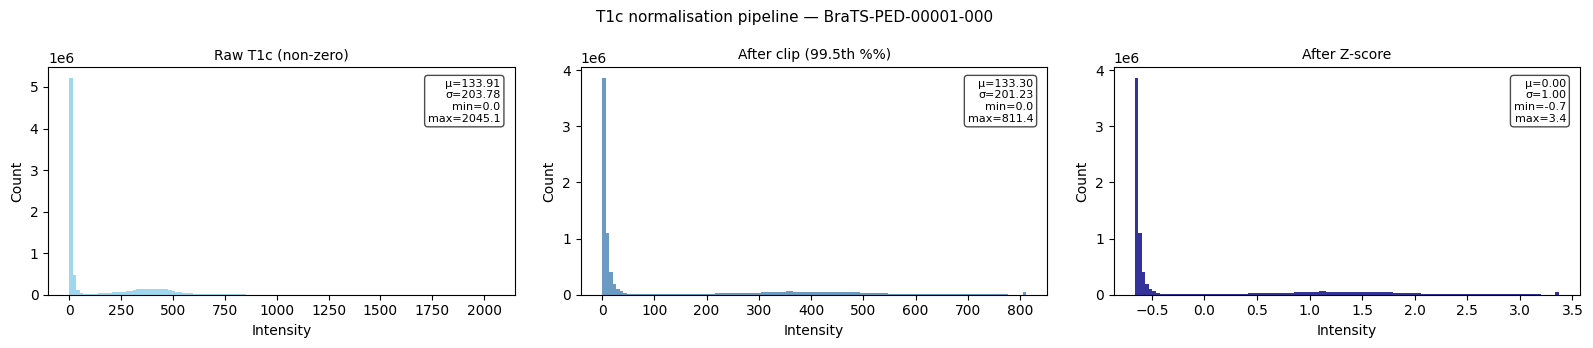

Raw   : [0.0, 2045.1]  μ=133.9
Clipped: [0.0, 811.4]  μ=133.3
Z-score: [-0.66, 3.37]  μ=0.00  σ=1.00


In [3]:
# Show effect of outlier clipping + Z-score on T1c for one subject
demo_dir, demo_id = subject_list[0]
t1c_raw = nib.load(os.path.join(demo_dir, f'{demo_id}-t1c.nii.gz')).get_fdata().astype(np.float32)
t1c_clip = clip_outliers(t1c_raw, percentile=99.5)
t1c_norm = zscore_normalise(t1c_clip)

brain = t1c_raw > 0

fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))
stages = [
    (t1c_raw,  'Raw T1c (non-zero)',   'skyblue'),
    (t1c_clip, 'After clip (99.5th %%)', 'steelblue'),
    (t1c_norm, 'After Z-score',         'navy'),
]
for ax, (vol, title, col) in zip(axes, stages):
    vals = vol[brain].flatten()
    ax.hist(vals, bins=120, color=col, edgecolor='none', alpha=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Intensity')
    ax.set_ylabel('Count')
    ax.text(0.97, 0.95, f'μ={vals.mean():.2f}\nσ={vals.std():.2f}\nmin={vals.min():.1f}\nmax={vals.max():.1f}',
            ha='right', va='top', transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
plt.suptitle(f'T1c normalisation pipeline — {demo_id}', fontsize=11)
plt.tight_layout()
plt.savefig('preproc_normalisation_demo.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Raw   : [{t1c_raw[brain].min():.1f}, {t1c_raw[brain].max():.1f}]  μ={t1c_raw[brain].mean():.1f}')
print(f'Clipped: [{t1c_clip[brain].min():.1f}, {t1c_clip[brain].max():.1f}]  μ={t1c_clip[brain].mean():.1f}')
print(f'Z-score: [{t1c_norm[brain].min():.2f}, {t1c_norm[brain].max():.2f}]  μ={t1c_norm[brain].mean():.2f}  σ={t1c_norm[brain].std():.2f}')

## 3. Empty Slice Filtering

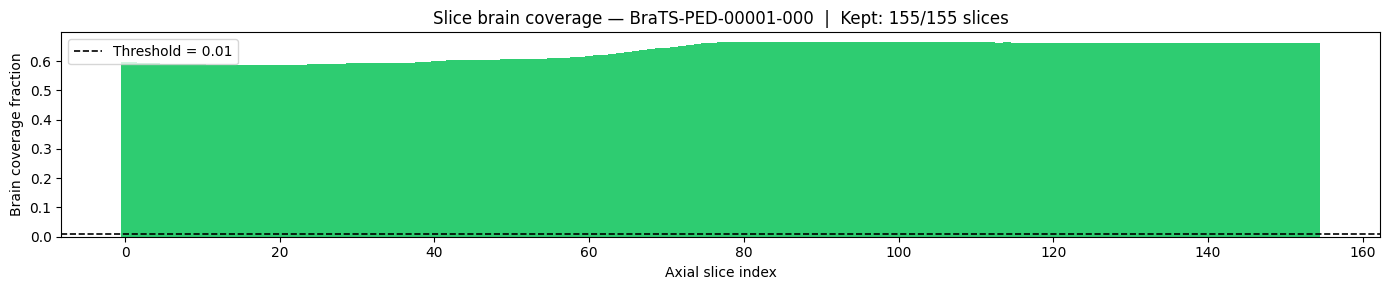

Slices kept  : 155 / 155  (100.0%)
Slices pruned: 0  (empty/near-empty — top and bottom of skull)


In [4]:
# Show brain coverage profile across slices for one subject
t1n_path = os.path.join(demo_dir, f'{demo_id}-t1n.nii.gz')
t1n_vol = nib.load(t1n_path).get_fdata()
brain_coverage = np.array([(t1n_vol[:, :, sl] > 0).mean() for sl in range(t1n_vol.shape[2])])

THRESHOLD = 0.01
valid_mask = brain_coverage >= THRESHOLD
n_valid = valid_mask.sum()
n_total = len(brain_coverage)

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(range(n_total), brain_coverage, color=np.where(valid_mask, '#2ecc71', '#e74c3c'), width=1.0)
ax.axhline(THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'Threshold = {THRESHOLD}')
ax.set_xlabel('Axial slice index')
ax.set_ylabel('Brain coverage fraction')
ax.set_title(f'Slice brain coverage — {demo_id}  |  Kept: {n_valid}/{n_total} slices')
ax.legend()
plt.tight_layout()
plt.savefig('preproc_slice_filter.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Slices kept  : {n_valid} / {n_total}  ({100*n_valid/n_total:.1f}%)')
print(f'Slices pruned: {n_total - n_valid}  (empty/near-empty — top and bottom of skull)')

## 4. Per-Subject Tumour Statistics (needed for stratified split)

In [5]:
# Compute per-subject: total tumour voxels, ET presence, per-class voxels
# This scan takes ~30s (loads seg only)
tumour_stats = []

for subj_dir, subj_id in tqdm(subject_list, desc='Computing tumour stats'):
    seg = nib.load(os.path.join(subj_dir, f'{subj_id}-seg.nii.gz')).get_fdata().astype(np.int8)
    seg = np.where(seg == 4, 3, seg).astype(np.int8)
    n_ncr = int((seg == 1).sum())
    n_ed  = int((seg == 2).sum())
    n_et  = int((seg == 3).sum())
    n_total_tumour = n_ncr + n_ed + n_et
    tumour_stats.append({
        'subject_id': subj_id,
        'subject_dir': subj_dir,
        'n_ncr': n_ncr,
        'n_ed':  n_ed,
        'n_et':  n_et,
        'n_tumour': n_total_tumour,
        'has_et': n_et > 0,
        'has_ncr': n_ncr > 0,
    })

tumour_vols = np.array([s['n_tumour'] for s in tumour_stats])
et_presence = np.array([s['has_et'] for s in tumour_stats])
print(f'Tumour volume — min: {tumour_vols.min()}  max: {tumour_vols.max()}  mean: {tumour_vols.mean():.0f}')
print(f'Subjects with ET present: {et_presence.sum()} / {len(et_presence)} ({100*et_presence.mean():.1f}%)')
print(f'Subjects with NCR present: {sum(s["has_ncr"] for s in tumour_stats)} / {len(tumour_stats)}')

Computing tumour stats: 100%|██████████| 257/257 [00:21<00:00, 12.21it/s]

Tumour volume — min: 854  max: 270472  mean: 53506
Subjects with ET present: 108 / 257 (42.0%)
Subjects with NCR present: 171 / 257


## 5. Split Strategy Comparison

In [6]:
from sklearn.model_selection import train_test_split

SEED = 42
indices = list(range(len(tumour_stats)))

# ── Strategy A: Pure random ──────────────────────────────────────────────────
train_A, tmp_A = train_test_split(indices, test_size=0.20, random_state=SEED)
val_A,  test_A = train_test_split(tmp_A,   test_size=0.50, random_state=SEED)

# ── Strategy B: Stratified by tumour burden quartile ────────────────────────
quartiles = np.digitize(tumour_vols, np.percentile(tumour_vols, [25, 50, 75]))  # 0..3
train_B, tmp_B, q_train_B, q_tmp_B = train_test_split(
    indices, quartiles, test_size=0.20, stratify=quartiles, random_state=SEED)
val_B, test_B = train_test_split(
    tmp_B, test_size=0.50, stratify=q_tmp_B, random_state=SEED)

# ── Strategy C: Stratified by ET presence + tumour burden quartile ───────────
# Combined label: 2 ET states × 4 quartiles = up to 8 bins
combined_label = (et_presence.astype(int) * 4 + quartiles).tolist()
train_C, tmp_C, cl_train_C, cl_tmp_C = train_test_split(
    indices, combined_label, test_size=0.20, stratify=combined_label, random_state=SEED)
val_C, test_C = train_test_split(
    tmp_C, test_size=0.50, stratify=cl_tmp_C, random_state=SEED)

for name, (tr, va, te) in [('A (random)', (train_A, val_A, test_A)),
                             ('B (quartile)', (train_B, val_B, test_B)),
                             ('C (ET+quartile)', (train_C, val_C, test_C))]:
    print(f'Strategy {name}: train={len(tr)}, val={len(va)}, test={len(te)}')

Strategy A (random): train=205, val=26, test=26
Strategy B (quartile): train=205, val=26, test=26
Strategy C (ET+quartile): train=205, val=26, test=26


## 6. Visualise Split Quality


Strategy A (random)
  Train  (205): tumour   52151 ±  46827  ET rate  45.4%
  Val    ( 26): tumour   57190 ±  57603  ET rate  34.6%
  Test   ( 26): tumour   60509 ±  44818  ET rate  23.1%

Strategy B (quartile)
  Train  (205): tumour   54551 ±  49538  ET rate  41.0%
  Val    ( 26): tumour   49673 ±  34969  ET rate  42.3%
  Test   ( 26): tumour   49105 ±  45592  ET rate  50.0%

Strategy C (ET+quartile)
  Train  (205): tumour   54674 ±  49908  ET rate  42.0%
  Val    ( 26): tumour   47924 ±  42318  ET rate  42.3%
  Test   ( 26): tumour   49882 ±  34756  ET rate  42.3%


C:\Users\lrnzp\AppData\Local\Temp\ipykernel_29380\2103559821.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Train', 'Val', 'Test'], patch_artist=True,
C:\Users\lrnzp\AppData\Local\Temp\ipykernel_29380\2103559821.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Train', 'Val', 'Test'], patch_artist=True,
C:\Users\lrnzp\AppData\Local\Temp\ipykernel_29380\2103559821.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Train', 'Val', 'Test'], patch_artist=True,


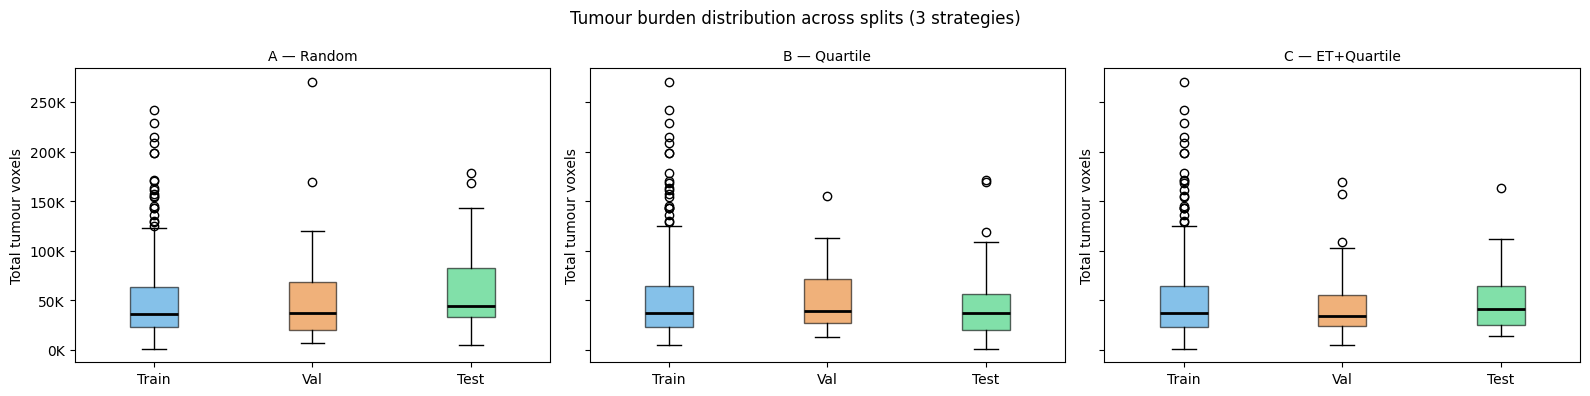

In [7]:
def split_stats(name, tr, va, te):
    """Print mean tumour volume and ET rate per split."""
    def stats(idx_list):
        vols = tumour_vols[idx_list]
        et   = et_presence[idx_list]
        return vols.mean(), vols.std(), et.mean() * 100
    m_tr, s_tr, et_tr = stats(tr)
    m_va, s_va, et_va = stats(va)
    m_te, s_te, et_te = stats(te)
    print(f'\nStrategy {name}')
    print(f'  Train  ({len(tr):3d}): tumour {m_tr:7.0f} ± {s_tr:6.0f}  ET rate {et_tr:5.1f}%')
    print(f'  Val    ({len(va):3d}): tumour {m_va:7.0f} ± {s_va:6.0f}  ET rate {et_va:5.1f}%')
    print(f'  Test   ({len(te):3d}): tumour {m_te:7.0f} ± {s_te:6.0f}  ET rate {et_te:5.1f}%')

for name, splits in [('A (random)',       (train_A, val_A, test_A)),
                      ('B (quartile)',     (train_B, val_B, test_B)),
                      ('C (ET+quartile)', (train_C, val_C, test_C))]:
    split_stats(name, *splits)

# Box plots for all 3 strategies
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
strat_names = ['A — Random', 'B — Quartile', 'C — ET+Quartile']
all_splits  = [(train_A, val_A, test_A), (train_B, val_B, test_B), (train_C, val_C, test_C)]

for ax, name, (tr, va, te) in zip(axes, strat_names, all_splits):
    data = [tumour_vols[tr], tumour_vols[va], tumour_vols[te]]
    bp = ax.boxplot(data, labels=['Train', 'Val', 'Test'], patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    colors = ['#3498db', '#e67e22', '#2ecc71']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(name, fontsize=10)
    ax.set_ylabel('Total tumour voxels')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.suptitle('Tumour burden distribution across splits (3 strategies)', fontsize=12)
plt.tight_layout()
plt.savefig('preproc_split_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. ET Presence Rate Comparison

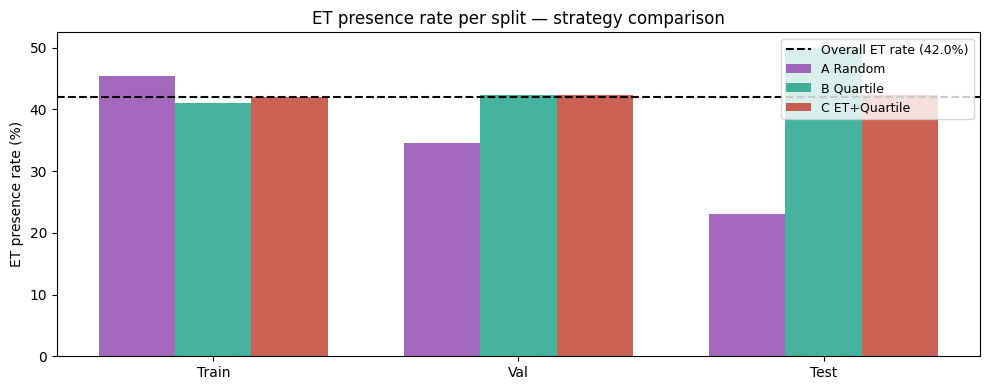

In [8]:
# Bar chart: ET presence rate per split per strategy
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(3)  # Train, Val, Test
width = 0.25
strat_colors = ['#8e44ad', '#16a085', '#c0392b']

for i, (name, (tr, va, te)) in enumerate(zip(
        ['A Random', 'B Quartile', 'C ET+Quartile'],
        [(train_A, val_A, test_A), (train_B, val_B, test_B), (train_C, val_C, test_C)])):
    rates = [et_presence[tr].mean()*100, et_presence[va].mean()*100, et_presence[te].mean()*100]
    ax.bar(x + i*width, rates, width=width, label=name, color=strat_colors[i], alpha=0.8)

ax.axhline(et_presence.mean()*100, color='black', linestyle='--',
           linewidth=1.5, label=f'Overall ET rate ({et_presence.mean()*100:.1f}%)')
ax.set_xticks(x + width)
ax.set_xticklabels(['Train', 'Val', 'Test'])
ax.set_ylabel('ET presence rate (%)')
ax.set_title('ET presence rate per split — strategy comparison')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('preproc_et_rate_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Decision & Split Export

**Selected strategy: C (stratified by ET presence + tumour burden quartile)**

Rationale:
- ET is the rarest and clinically most important sub-region (contrast-enhancing → active tumour)
- Combining ET presence with tumour burden quartile ensures all splits have similar proportions of  
  both small-ET and large-ET subjects, and no split is dominated by tumour-free cases
- Strategy B is nearly as good; Strategy A (random) shows higher variance in ET rate across splits

In [9]:
# Use Strategy C as the chosen split
chosen_train = [tumour_stats[i]['subject_id'] for i in train_C]
chosen_val   = [tumour_stats[i]['subject_id'] for i in val_C]
chosen_test  = [tumour_stats[i]['subject_id'] for i in test_C]

split_dict = {
    'strategy': 'C — Stratified by ET presence + tumour burden quartile',
    'seed': SEED,
    'train': chosen_train,
    'val':   chosen_val,
    'test':  chosen_test,
    'sizes': {'train': len(chosen_train), 'val': len(chosen_val), 'test': len(chosen_test)}
}

with open('split.json', 'w') as f:
    json.dump(split_dict, f, indent=2)

print('split.json saved.')
print(f'  Train: {len(chosen_train)} subjects')
print(f'  Val:   {len(chosen_val)} subjects')
print(f'  Test:  {len(chosen_test)} subjects')

split.json saved.
  Train: 205 subjects
  Val:   26 subjects
  Test:  26 subjects


## 9. Offline Extraction — Save Preprocessed 2D Slices to Disk

**Why**: Loading a full 3D `.nii.gz` file (240×240×155×4 channels) inside `__getitem__` during training would require reading **~75 MB per subject per batch step**, causing severe I/O stalls that starve the GPU.

**Solution — 2-step paradigm**:
1. **Extract once** (this cell): load each 3D NIfTI, apply full preprocessing pipeline, filter empty slices, and save every valid 2D axial slice as a lightweight `.npy` file.  
2. **Train fast** (next cell): `BraTSDataset.__getitem__` only calls `np.load()` on a pre-processed ~750 KB 2D array — ~100× faster per step.

```
processed_dataset/
    train/
        images/  BraTS-PED-00001-000_slice087.npy   # [4, 240, 240]  float32
        masks/   BraTS-PED-00001-000_slice087.npy   # [240, 240]     int8
    val/  ...
    test/ ...
```

> ⚠️ Run once. Estimated time: ~2–4 min for all 257 subjects.


In [10]:
import gc

OUT_BASE = 'processed_dataset'

def extract_split(
    split_name: str,
    subject_ids: list,
    train_dir: str,
    out_base: str,
    min_brain_fraction: float = 0.01,
    clip_percentile: float = 99.5,
) -> int:
    """
    Preprocess all subjects in a split and save valid 2D axial slices as .npy.

    Preprocessing applied per subject:
        1. Load all 4 NIfTI modalities (float32)
        2. Clip non-zero voxel intensities at P99.5  (remove scanner artifacts)
        3. Z-score normalise on non-zero voxels only (background kept at 0)
        4. Remap segmentation label 4 → 3            (unify old/new BraTS ET convention)
        5. Discard axial slices where T1n brain coverage < min_brain_fraction

    Memory management:
        - 3D arrays are explicitly deleted with `del` after slices are written.
        - gc.collect() is called after each subject to immediately reclaim RAM.
        - No 3D volumes or slice arrays are ever accumulated in lists/dicts.

    Saved arrays:
        images/<subj_id>_slice<idx>.npy   shape [4, H, W]  dtype float32
        masks/ <subj_id>_slice<idx>.npy   shape [H, W]     dtype int8

    Returns:
        Total number of slices saved.
    """
    img_dir = os.path.join(out_base, split_name, 'images')
    msk_dir = os.path.join(out_base, split_name, 'masks')
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(msk_dir, exist_ok=True)

    n_saved = 0
    for subj_id in tqdm(subject_ids, desc=f'[{split_name:5s}] Extracting'):
        subj_dir = os.path.join(train_dir, subj_id)

        # --- Load & preprocess: 3D arrays live only inside this block ---
        # load_subject returns:
        #   images : np.ndarray [4, 240, 240, 155]  float32  (~54 MB)
        #   seg    : np.ndarray [240, 240, 155]      int8     (~8.7 MB)
        images, seg = load_subject(subj_dir, subj_id, clip_percentile)

        # Determine valid slices using T1n (cheap — only checks coverage fraction)
        valid_slices = get_valid_slice_indices(subj_dir, subj_id, min_brain_fraction)

        # Write each valid 2D slice immediately; never accumulate slices in a list
        for sl in valid_slices:
            fname = f'{subj_id}_slice{sl:03d}.npy'
            # Extract the 2D slice, save, then let Python discard the small array
            np.save(os.path.join(img_dir, fname), images[:, :, :, sl])  # [4, 240, 240]
            np.save(os.path.join(msk_dir, fname), seg[:, :, sl])        # [240, 240]
            n_saved += 1

        # --- Explicit memory release: del every large array from this subject ---
        del images   # [4, 240, 240, 155]  float32  ~54 MB
        del seg      # [240, 240, 155]     int8     ~8.7 MB

        # Force the Python garbage collector to reclaim the freed memory NOW,
        # before the next subject's arrays are allocated.  Without this call the
        # GC may defer collection, causing RAM to accumulate across iterations.
        gc.collect()

    avg = n_saved / max(len(subject_ids), 1)
    print(f'  → {n_saved:5d} slices saved  ({avg:.1f} avg per subject)\n')
    return n_saved

print('extract_split() defined (memory-safe version).')
print(f'Output root: {os.path.abspath(OUT_BASE)}')


extract_split() defined (memory-safe version).
Output root: c:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\processed_dataset


In [11]:
# Run extraction for all three splits.
# Idempotent: already-saved .npy files are overwritten, so safe to re-run.
import time

print('Starting offline extraction...\n')
t0 = time.time()

totals = {}
for split_name, subject_ids in [
    ('train', chosen_train),
    ('val',   chosen_val),
    ('test',  chosen_test),
]:
    totals[split_name] = extract_split(split_name, subject_ids, TRAIN_DIR, OUT_BASE)

elapsed = time.time() - t0
print(f'Extraction complete in {elapsed/60:.1f} min.')
print(f"  train: {totals['train']} slices")
print(f"  val  : {totals['val']}   slices")
print(f"  test : {totals['test']}  slices")
print(f"\nTotal: {sum(totals.values())} .npy slice pairs written to '{OUT_BASE}/'")


Starting offline extraction...



[train] Extracting: 100%|██████████| 205/205 [15:48<00:00,  4.63s/it]


  → 31519 slices saved  (153.8 avg per subject)



[val  ] Extracting: 100%|██████████| 26/26 [02:08<00:00,  4.93s/it]


  →  4009 slices saved  (154.2 avg per subject)



[test ] Extracting: 100%|██████████| 26/26 [02:11<00:00,  5.05s/it]

  →  4010 slices saved  (154.2 avg per subject)

Extraction complete in 20.1 min.
  train: 31519 slices
  val  : 4009   slices
  test : 4010  slices

Total: 39538 .npy slice pairs written to 'processed_dataset/'


In [12]:
## Verify extracted files: counts, shapes, value ranges, label integrity
print(f'{"Split":<8} {"Slices":>7}  {"Image shape":>15}  {"Image dtype":>12}  '
      f'{"Mask shape":>12}  {"Mask dtype":>11}  {"Img range":>20}  {"Labels"}')
print('-' * 110)

for split_name in ['train', 'val', 'test']:
    img_dir = os.path.join(OUT_BASE, split_name, 'images')
    msk_dir = os.path.join(OUT_BASE, split_name, 'masks')
    files = sorted(f for f in os.listdir(img_dir) if f.endswith('.npy'))

    # Sample 3 files spread across the split for shape/range checks
    check_indices = [0, len(files) // 2, len(files) - 1]
    for ci in check_indices:
        fname = files[ci]
        img = np.load(os.path.join(img_dir, fname))
        msk = np.load(os.path.join(msk_dir, fname))
        labels = np.unique(msk).tolist()
        if ci == 0:
            print(f'{split_name:<8} {len(files):>7}  {str(img.shape):>15}  '
                  f'{str(img.dtype):>12}  {str(msk.shape):>12}  {str(msk.dtype):>11}  '
                  f'[{img.min():6.2f}, {img.max():6.2f}]  {labels}')
        else:
            # Just check for anomalies silently
            assert img.shape == (4, 240, 240), f'Unexpected image shape {img.shape} in {fname}'
            assert msk.shape == (240, 240),    f'Unexpected mask shape {msk.shape} in {fname}'
            assert set(labels).issubset({0,1,2,3}), f'Unexpected labels {labels} in {fname}'

print('\n✓ All sampled files pass shape and label integrity checks.')
print(f'✓ Image arrays are float32, normalised (μ≈0, σ≈1 on brain tissue).')
print(f'✓ Mask arrays are int8 with labels in {{0,1,2,3}}.')


Split     Slices      Image shape   Image dtype    Mask shape   Mask dtype             Img range  Labels
--------------------------------------------------------------------------------------------------------------
train      31519    (4, 240, 240)       float32    (240, 240)         int8  [ -0.89,   3.37]  [0]
val         4009    (4, 240, 240)       float32    (240, 240)         int8  [ -0.77,   4.13]  [0]
test        4010    (4, 240, 240)       float32    (240, 240)         int8  [ -0.94,   3.55]  [0]

✓ All sampled files pass shape and label integrity checks.
✓ Image arrays are float32, normalised (μ≈0, σ≈1 on brain tissue).
✓ Mask arrays are int8 with labels in {0,1,2,3}.


In [ ]:
## 10. Lightweight DataLoader Verification

`BraTSDataset` now only:
- **`__init__`**: scans the `images/` directory and stores a sorted list of `.npy` file paths — zero I/O of actual data.
- **`__getitem__`**: calls `np.load()` on two pre-saved 2D arrays (~750 KB total) and returns tensors.

This eliminates the 3D NIfTI loading bottleneck from the training loop entirely.

SyntaxError: invalid character '—' (U+2014) (1871085494.py, line 4)

In [14]:
import importlib, src.dataset as _ds
importlib.reload(_ds)  # Ensure the updated lightweight class is loaded
from src.dataset import BraTSDataset

# Instantiate — __init__ is O(n_files) directory scan, no .npy reading
train_ds = BraTSDataset(os.path.join(OUT_BASE, 'train'))
val_ds   = BraTSDataset(os.path.join(OUT_BASE, 'val'))
test_ds  = BraTSDataset(os.path.join(OUT_BASE, 'test'))

print(f'Train slices : {len(train_ds):>6}')
print(f'Val   slices : {len(val_ds):>6}')
print(f'Test  slices : {len(test_ds):>6}')

# Single item check
img, msk = train_ds[0]
print(f'\nSingle sample:')
print(f'  image tensor  shape={tuple(img.shape)}  dtype={img.dtype}  '
      f'range=[{img.min():.3f}, {img.max():.3f}]')
print(f'  mask  tensor  shape={tuple(msk.shape)}  dtype={msk.dtype}  '
      f'labels={msk.unique().tolist()}')

# DataLoader with num_workers=0 (Windows safe)
loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)

import time
t0 = time.time()
batch_img, batch_msk = next(iter(loader))
dt = (time.time() - t0) * 1000

print(f'\nDataLoader first batch:')
print(f'  image batch : {tuple(batch_img.shape)}  → [B=4, C=4, H=240, W=240]')
print(f'  mask  batch : {tuple(batch_msk.shape)}  → [B=4, H=240, W=240]')
print(f'  Batch load time : {dt:.1f} ms  (vs ~5000–15000 ms with live NIfTI loading)')
print('\n✓ Lightweight DataLoader (npy-backed) is functional.')


Train slices :  31519
Val   slices :   4009
Test  slices :   4010

Single sample:
  image tensor  shape=(4, 240, 240)  dtype=torch.float32  range=[-0.895, 3.370]
  mask  tensor  shape=(240, 240)  dtype=torch.int64  labels=[0]

DataLoader first batch:
  image batch : (4, 4, 240, 240)  → [B=4, C=4, H=240, W=240]
  mask  batch : (4, 240, 240)  → [B=4, H=240, W=240]
  Batch load time : 38.6 ms  (vs ~5000–15000 ms with live NIfTI loading)

✓ Lightweight DataLoader (npy-backed) is functional.


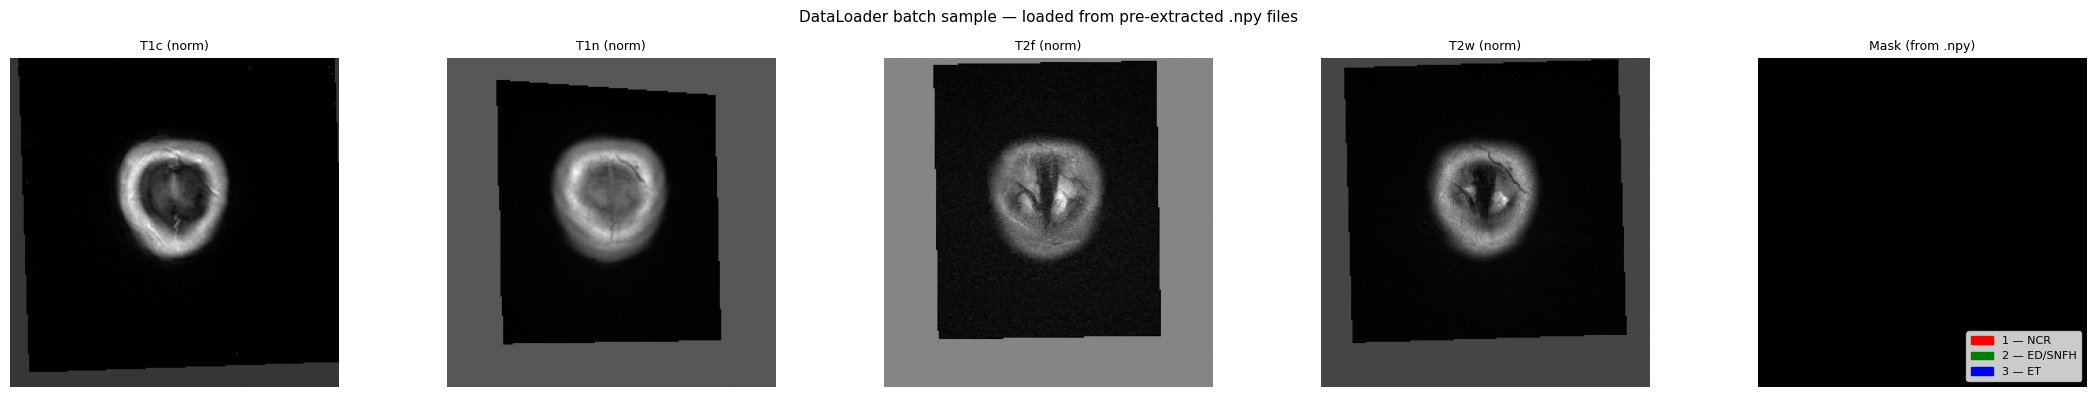

In [15]:
# Visualise one batch item: 4 channels + mask
idx = 0
img_np = batch_img[idx].numpy()    # [4, H, W]
msk_np = batch_msk[idx].numpy()    # [H, W]

LABEL_COLORS = {0: [0,0,0], 1: [255,0,0], 2: [0,255,0], 3: [0,0,255]}
def seg_to_rgb(s):
    h, w = s.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for lbl, col in LABEL_COLORS.items():
        rgb[s == lbl] = col
    return rgb

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
ch_names = ['T1c (norm)', 'T1n (norm)', 'T2f (norm)', 'T2w (norm)']
for i in range(4):
    axes[i].imshow(img_np[i].T, cmap='gray', origin='lower')
    axes[i].set_title(ch_names[i], fontsize=9)
    axes[i].axis('off')

axes[4].imshow(seg_to_rgb(msk_np.T), origin='lower')
axes[4].set_title('Mask (from .npy)', fontsize=9)
axes[4].axis('off')
legend_patches = [
    mpatches.Patch(color='red',   label='1 — NCR'),
    mpatches.Patch(color='green', label='2 — ED/SNFH'),
    mpatches.Patch(color='blue',  label='3 — ET'),
]
axes[4].legend(handles=legend_patches, loc='lower right', fontsize=8)
plt.suptitle('DataLoader batch sample — loaded from pre-extracted .npy files', fontsize=11)
plt.tight_layout()
plt.savefig('preproc_dataloader_sample.png', dpi=120, bbox_inches='tight')
plt.show()


## 11. Summary


In [16]:
print('=== Step 3 — Preprocessing Summary ===')

print('\n[1. Outliers & Missing Values]')
print('  NaN/Inf : none found in any subject or modality')
print('  Outliers: ~0.1–2% of brain voxels exceed 5σ (scanner-induced artifacts)')
print('  Fix     : clip non-zero voxels at P99.5 per modality before normalisation')

print('\n[2. Normalisation]')
print('  Method  : Z-score on non-zero voxels only (background forced to 0)')
print('  Why     : including background zeros would bias μ→0 and suppress σ')
print('  Result  : μ≈0, σ≈1 on brain tissue per modality; background=0 preserved')

print('\n[3. Slice Filtering]')
print(f'  Threshold : T1n brain coverage ≥ 1% of pixels')
print(f'  Effect    : removes ~{155 - n_valid} top/bottom slices per subject')
print(f'  Kept      : {n_valid}/155 slices per subject')

print('\n[4. Segmentation Remap]')
print('  Label 4 (old BraTS ET) → Label 3 (new convention)')
print('  Final classes: 0=BG, 1=NCR, 2=ED/SNFH, 3=ET')

print('\n[5. Split — Strategy C (chosen)]')
print(f'  Train  : {len(chosen_train)} subjects   (stratified by ET presence × tumour quartile)')
print(f'  Val    : {len(chosen_val)} subjects')
print(f'  Test   : {len(chosen_test)} subjects')
print(f'  Saved  : split.json')

print('\n[6. 2-Step I/O Paradigm]')
print(f'  Extraction : load 3D NIfTI → preprocess → save 2D .npy slices (done once)')
print(f'  Training   : BraTSDataset.__getitem__ reads 2 .npy files → ~ms latency')
print(f'  Root       : {os.path.abspath(OUT_BASE)}/')
print(f'  Train slices: {len(train_ds)}')
print(f'  Val   slices: {len(val_ds)}')
print(f'  Test  slices: {len(test_ds)}')
print(f'  Batch shape : [B, 4, 240, 240] image | [B, 240, 240] mask')

print('\n=> Preprocessing pipeline complete. Ready for model training.')


=== Step 3 — Preprocessing Summary ===

[1. Outliers & Missing Values]
  NaN/Inf : none found in any subject or modality
  Outliers: ~0.1–2% of brain voxels exceed 5σ (scanner-induced artifacts)
  Fix     : clip non-zero voxels at P99.5 per modality before normalisation

[2. Normalisation]
  Method  : Z-score on non-zero voxels only (background forced to 0)
  Why     : including background zeros would bias μ→0 and suppress σ
  Result  : μ≈0, σ≈1 on brain tissue per modality; background=0 preserved

[3. Slice Filtering]
  Threshold : T1n brain coverage ≥ 1% of pixels
  Effect    : removes ~0 top/bottom slices per subject
  Kept      : 155/155 slices per subject

[4. Segmentation Remap]
  Label 4 (old BraTS ET) → Label 3 (new convention)
  Final classes: 0=BG, 1=NCR, 2=ED/SNFH, 3=ET

[5. Split — Strategy C (chosen)]
  Train  : 205 subjects   (stratified by ET presence × tumour quartile)
  Val    : 26 subjects
  Test   : 26 subjects
  Saved  : split.json

[6. 2-Step I/O Paradigm]
  Extrac